In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [6]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [7]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)), # input_shape=(height,width,channels) The filter size (e.g., (3,3)) does indeed determine how the filter slides across the image (through strides and padding)# while filter size governs local processing, the input shape informs the model about overall dimensions, enabling it to build the correct computational graph# the model needs to know the full size of the input image before the first layer starts processing. That's where input_shape=(height, width, channels) comes in!
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
# from tensorflow.keras.layers import Reshape

In [10]:
# model.add(Reshape((10, 10)))  # This will reshape the output tensor

In [11]:
# Train the Model
model.summary()
# batch_size = 32
history = model.fit(x_train, y_train, epochs=7, validation_data=(x_test, y_test)) # can add  batch_size=batch_size

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.3108 - loss: 2.5041 - val_accuracy: 0.5012 - val_loss: 1.3810
Epoch 2/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5212 - loss: 1.3472 - val_accuracy: 0.5574 - val_loss: 1.2362
Epoch 3/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5831 - loss: 1.1921 - val_accuracy: 0.5948 - val_loss: 1.1805
Epoch 4/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6264 - loss: 1.0571 - val_accuracy: 0.6048 - val_loss: 1.1377
Epoch 5/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6603 - loss: 0.9735 - val_accuracy: 0.6479 - val_loss: 1.0268
Epoch 6/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6854 - loss: 0.8958 - val_accuracy: 0.6575 - val_loss: 1.0126
Epoch 7/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7066 - loss: 0.8440 - val_accuracy: 0.6703 - val_loss: 0.9887


In [12]:
# Step 6: Evaluate the Model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f'\nTest Accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6739 - loss: 0.9697

Test Accuracy: 0.6703


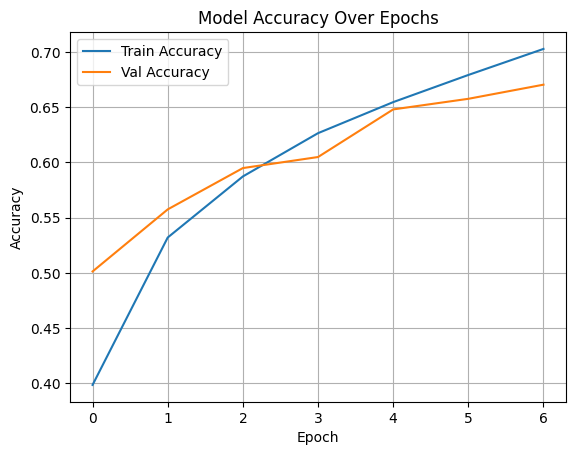

In [13]:
# Step 7: Visualize Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.title('Model Accuracy Over Epochs')
plt.show()

In [14]:
# Make Predictions
predictions = model.predict(x_test[:5])
print("\nPredicted class probabilities for first 5 test images:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step

Predicted class probabilities for first 5 test images:
[[2.9548674e-03 6.1117479e-04 1.5415714e-02 7.7572072e-01 2.9916735e-03
  9.8290227e-02 4.7957260e-02 1.9686562e-03 5.3053092e-02 1.0365456e-03]
 [4.5446236e-06 1.6112927e-02 2.6580633e-09 3.2581549e-10 1.2615628e-12
  7.4501204e-12 1.3518038e-11 3.8459223e-12 9.8380417e-01 7.8395016e-05]
 [2.5101575e-01 6.1355121e-02 7.2331667e-02 1.4224321e-02 6.3007451e-03
  4.9937181e-03 3.2417886e-03 2.1670496e-03 5.5698884e-01 2.7380964e-02]
 [8.3041525e-01 5.5214990e-02 1.8622216e-02 1.2806247e-02 6.9710235e-03
  1.5184535e-03 2.2348999e-03 8.7228126e-04 5.1276773e-02 2.0067859e-02]
 [5.7200581e-05 2.0476260e-04 1.1778123e-02 1.9651705e-02 4.8098183e-01
  7.4353861e-03 4.7919536e-01 2.9354324e-04 2.8465447e-05 3.7357939e-04]]


In [15]:
# Display first 5 test images with predicted labels
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

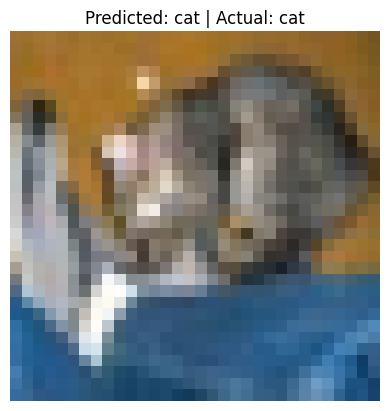

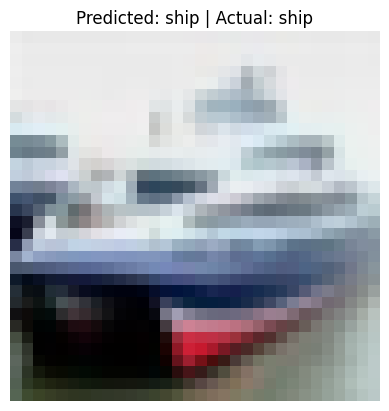

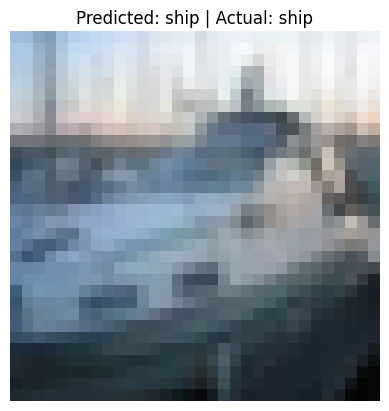

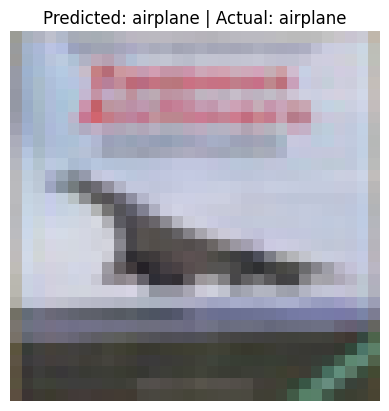

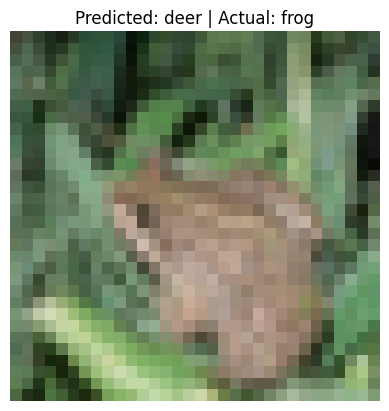

In [16]:
for i in range(5):
    plt.imshow(x_test[i])
    plt.title(f"Predicted: {class_names[np.argmax(predictions[i])]} | Actual: {class_names[np.argmax(y_test[i])]}")
    plt.axis('off')
    plt.show()

In [17]:
model.save('my_model.keras')
print("Model Saved!")

Model Saved!


In [20]:
# from tensorflow.keras.models import load_model

In [21]:
'''saved_model = load_model('my_model.keras')
if saved_model is not None:
  print("Model loaded!")
else:
  print("Model not loaded")'''

'saved_model = load_model(\'my_model.keras\')\nif saved_model is not None:\n  print("Model loaded!")\nelse:\n  print("Model not loaded")'